In [1]:
# Importing the libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Conv2D, MaxPool2D, Flatten, Dropout


import os 
import zipfile

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
#downloading the data
!wget --no-check-certificate \
    https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
    -O /cats_and_dogs_filtered.zip

--2022-09-27 03:46:57--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.99.128, 173.194.203.128, 74.125.199.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.99.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/cats_and_dogs_filtered.zip’

/cats_and_dogs_filt 100%[===================>]  65.43M   146MB/s    in 0.4s    

2022-09-27 03:46:57 (146 MB/s) - ‘/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [3]:
# Unzipping the data
dataset_path = "/cats_and_dogs_filtered.zip"

zip_object = zipfile.ZipFile(file =dataset_path, mode="r")

zip_object.extractall("./")
zip_object.close()

In [4]:
#Creating directory
dataset_path_new = "/content/cats_and_dogs_filtered"

train_dir = os.path.join(dataset_path_new, "train")

valid_dir = os.path.join(dataset_path_new, "validation")

In [5]:
# Instantiating the Image data generator
data_gen_train = ImageDataGenerator(rescale=1/255)

data_gen_valid = ImageDataGenerator(rescale=1/255)

In [6]:
#Scaling the data
train_gen = data_gen_train.flow_from_directory(train_dir, target_size=(128,128),
                                               batch_size = 128, class_mode = "binary")

valid_gen = data_gen_train.flow_from_directory(valid_dir, target_size=(128,128),
                                               batch_size = 128, class_mode = "binary")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [7]:
# Building the body of the model Using VGG19
base_model = tf.keras.applications.VGG19(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False

80150528/80134624 [==============================] - 0s 0us/step


In [8]:
base_model.summary()

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [29]:
#Creating the Head of the model
model = Flatten()(base_model.output)

model = Dense(units=500, activation="relu")(model)
#model = Dense(units=100, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model)

In [30]:
# Joining the head and body
model = Model(inputs= base_model.input, outputs = prediction_layer)

In [31]:
#Summarising the model
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [32]:
# Compiling and training 
model.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  after removing the cwd from sys.path.


Epoch 1/6
16/16 [==============================] - 10s 609ms/step - loss: 2.1544 - sparse_categorical_accuracy: 0.5625 - val_loss: 0.7716 - val_sparse_categorical_accuracy: 0.5220
Epoch 2/6
16/16 [==============================] - 9s 584ms/step - loss: 0.4769 - sparse_categorical_accuracy: 0.7655 - val_loss: 0.4066 - val_sparse_categorical_accuracy: 0.7970
Epoch 3/6
16/16 [==============================] - 9s 588ms/step - loss: 0.3376 - sparse_categorical_accuracy: 0.8580 - val_loss: 0.3509 - val_sparse_categorical_accuracy: 0.8460
Epoch 4/6
16/16 [==============================] - 9s 586ms/step - loss: 0.2847 - sparse_categorical_accuracy: 0.8885 - val_loss: 0.3330 - val_sparse_categorical_accuracy: 0.8600
Epoch 5/6
16/16 [==============================] - 9s 588ms/step - loss: 0.2529 - sparse_categorical_accuracy: 0.9070 - val_loss: 0.3097 - val_sparse_categorical_accuracy: 0.8680
Epoch 6/6
16/16 [==============================] - 9s 588ms/step - loss: 0.2158 - sparse_categorical_acc

Text(0.5, 1.0, 'Training-Validation Accuracy')

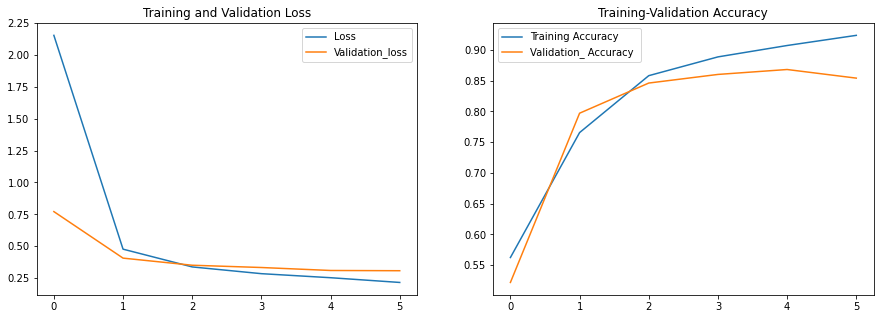

In [34]:
#saving the losses
loss = pd.DataFrame(model.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

# Transfer learning Using Mobile Net architecture

In [35]:
# Building the body of the model Using VGG19
base_model = tf.keras.applications.MobileNet(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False

17235968/17225924 [==============================] - 0s 0us/step


In [36]:
base_model.summary()

Model: "mobilenet_1.00_128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 32)        864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 64, 64, 32)       128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)       288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 64, 64, 32)       128       
 ation)                                         

In [37]:
#Creating the Head of the model
model = Flatten()(base_model.output)

model = Dense(units=500, activation="relu")(model)
#model = Dense(units=512, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model)

In [38]:
# Joining the head and body
model = Model(inputs= base_model.input, outputs = prediction_layer)

In [39]:
#Summarising the model
model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 64, 64, 32)        864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 64, 64, 32)       128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 64, 64, 32)        0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 64, 64, 32)       288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 64, 64, 32)       128       
 ation)                                                    

In [40]:
# Compiling and training 
model.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  after removing the cwd from sys.path.


Epoch 1/6
16/16 [==============================] - 11s 555ms/step - loss: 8.1858 - sparse_categorical_accuracy: 0.6725 - val_loss: 0.4961 - val_sparse_categorical_accuracy: 0.7040
Epoch 2/6
16/16 [==============================] - 8s 500ms/step - loss: 0.3247 - sparse_categorical_accuracy: 0.7680 - val_loss: 0.1808 - val_sparse_categorical_accuracy: 0.9400
Epoch 3/6
16/16 [==============================] - 8s 490ms/step - loss: 0.1036 - sparse_categorical_accuracy: 0.9560 - val_loss: 0.0896 - val_sparse_categorical_accuracy: 0.9680
Epoch 4/6
16/16 [==============================] - 8s 527ms/step - loss: 0.0638 - sparse_categorical_accuracy: 0.9770 - val_loss: 0.0760 - val_sparse_categorical_accuracy: 0.9740
Epoch 5/6
16/16 [==============================] - 8s 508ms/step - loss: 0.0397 - sparse_categorical_accuracy: 0.9875 - val_loss: 0.0678 - val_sparse_categorical_accuracy: 0.9740
Epoch 6/6
16/16 [==============================] - 8s 499ms/step - loss: 0.0264 - sparse_categorical_acc

Text(0.5, 1.0, 'Training-Validation Accuracy')

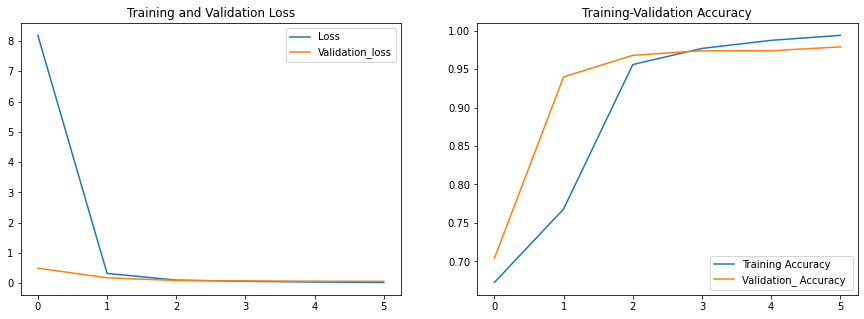

In [41]:
#saving the losses
loss = pd.DataFrame(model.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

VGG16

In [43]:
# Building the body of the model Using VGG19
base_model3= tf.keras.applications.VGG16(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False


In [44]:
base_model3.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [47]:
model3= Flatten()(base_model3.output)

model3= Dense(units=500, activation="relu")(model3)
#model = Dense(units=512, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model3)

In [48]:
# Joining the head and body
model3= Model(inputs= base_model3.input, outputs = prediction_layer)

In [49]:
model3.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [50]:
model3.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model3.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  This is separate from the ipykernel package so we can avoid doing imports until


Epoch 1/6
16/16 [==============================] - 23s 1s/step - loss: 1.5167 - sparse_categorical_accuracy: 0.4905 - val_loss: 0.6979 - val_sparse_categorical_accuracy: 0.5000
Epoch 2/6
16/16 [==============================] - 12s 717ms/step - loss: 0.6984 - sparse_categorical_accuracy: 0.5205 - val_loss: 0.6936 - val_sparse_categorical_accuracy: 0.5000
Epoch 3/6
16/16 [==============================] - 12s 745ms/step - loss: 0.6938 - sparse_categorical_accuracy: 0.5200 - val_loss: 0.6939 - val_sparse_categorical_accuracy: 0.5000
Epoch 4/6
16/16 [==============================] - 12s 737ms/step - loss: 0.6883 - sparse_categorical_accuracy: 0.5385 - val_loss: 0.6685 - val_sparse_categorical_accuracy: 0.6280
Epoch 5/6
16/16 [==============================] - 12s 733ms/step - loss: 0.6955 - sparse_categorical_accuracy: 0.5625 - val_loss: 0.6778 - val_sparse_categorical_accuracy: 0.6280
Epoch 6/6
16/16 [==============================] - 12s 718ms/step - loss: 0.6881 - sparse_categorical_a

Text(0.5, 1.0, 'Training-Validation Accuracy')

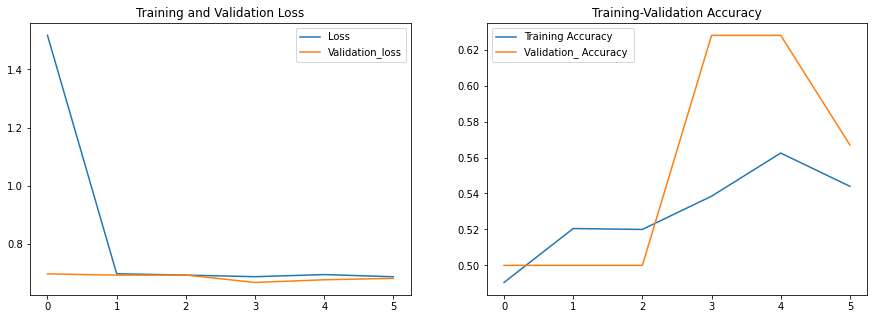

In [51]:
#saving the losses
loss = pd.DataFrame(model3.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

Inception v3

In [53]:
# Building the body of the model Using inception v3
base_model = tf.keras.applications.InceptionV3(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False

In [54]:
base_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 63, 63, 32)   864         ['input_6[0][0]']                
                                                                                                  
 batch_normalization_94 (BatchN  (None, 63, 63, 32)  96          ['conv2d_94[0][0]']              
 ormalization)                                                                                    
                                                                                       

In [55]:
#Creating the Head of the model
model = Flatten()(base_model.output)

model = Dense(units=500, activation="relu")(model)
#model = Dense(units=100, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model)

In [56]:
# Joining the head and body
model = Model(inputs= base_model.input, outputs = prediction_layer)

In [57]:
#Summarising the model
model.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 63, 63, 32)   864         ['input_6[0][0]']                
                                                                                                  
 batch_normalization_94 (BatchN  (None, 63, 63, 32)  96          ['conv2d_94[0][0]']              
 ormalization)                                                                                    
                                                                                            

In [58]:
# Compiling and training 
model.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  after removing the cwd from sys.path.


Epoch 1/6
16/16 [==============================] - 17s 763ms/step - loss: 6.5209 - sparse_categorical_accuracy: 0.7415 - val_loss: 0.8187 - val_sparse_categorical_accuracy: 0.8800
Epoch 2/6
16/16 [==============================] - 8s 509ms/step - loss: 0.5505 - sparse_categorical_accuracy: 0.9130 - val_loss: 0.3942 - val_sparse_categorical_accuracy: 0.9040
Epoch 3/6
16/16 [==============================] - 8s 508ms/step - loss: 0.2810 - sparse_categorical_accuracy: 0.9280 - val_loss: 0.2555 - val_sparse_categorical_accuracy: 0.9180
Epoch 4/6
16/16 [==============================] - 8s 513ms/step - loss: 0.1684 - sparse_categorical_accuracy: 0.9455 - val_loss: 0.2374 - val_sparse_categorical_accuracy: 0.9140
Epoch 5/6
16/16 [==============================] - 8s 515ms/step - loss: 0.1192 - sparse_categorical_accuracy: 0.9560 - val_loss: 0.2177 - val_sparse_categorical_accuracy: 0.9180
Epoch 6/6
16/16 [==============================] - 8s 516ms/step - loss: 0.0886 - sparse_categorical_acc

Text(0.5, 1.0, 'Training-Validation Accuracy')

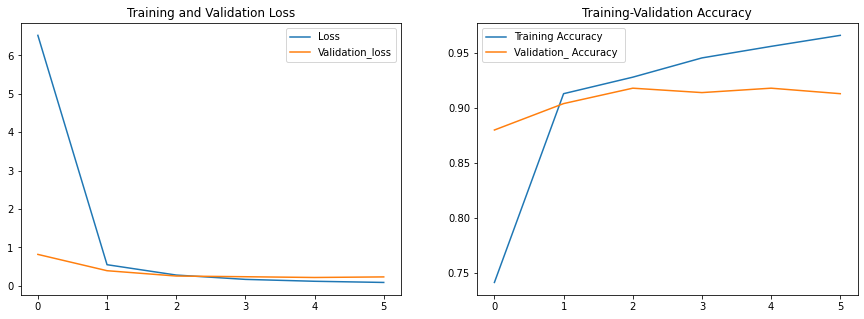

In [59]:
#saving the losses
loss = pd.DataFrame(model.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

ResNet 50

In [60]:
# Building the body of the model Using VGG19
base_model = tf.keras.applications.ResNet50(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False

94781440/94765736 [==============================] - 1s 0us/step


In [61]:
base_model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_7[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']      

In [62]:
#Creating the Head of the model
model = Flatten()(base_model.output)

model = Dense(units=500, activation="relu")(model)
#model = Dense(units=100, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model)

In [63]:
model = Model(inputs= base_model.input, outputs = prediction_layer)

In [64]:
#Summarising the model
model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_7[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

In [65]:
# Compiling and training 
model.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  after removing the cwd from sys.path.


Epoch 1/6
16/16 [==============================] - 16s 709ms/step - loss: 1.6419 - sparse_categorical_accuracy: 0.5030 - val_loss: 0.9451 - val_sparse_categorical_accuracy: 0.5040
Epoch 2/6
16/16 [==============================] - 9s 538ms/step - loss: 0.7285 - sparse_categorical_accuracy: 0.5470 - val_loss: 0.6882 - val_sparse_categorical_accuracy: 0.5530
Epoch 3/6
16/16 [==============================] - 8s 530ms/step - loss: 0.6626 - sparse_categorical_accuracy: 0.5865 - val_loss: 0.6674 - val_sparse_categorical_accuracy: 0.5720
Epoch 4/6
16/16 [==============================] - 8s 528ms/step - loss: 0.6466 - sparse_categorical_accuracy: 0.6170 - val_loss: 0.6491 - val_sparse_categorical_accuracy: 0.6030
Epoch 5/6
16/16 [==============================] - 8s 533ms/step - loss: 0.6252 - sparse_categorical_accuracy: 0.6515 - val_loss: 0.6376 - val_sparse_categorical_accuracy: 0.6510
Epoch 6/6
16/16 [==============================] - 8s 530ms/step - loss: 0.6148 - sparse_categorical_acc

Text(0.5, 1.0, 'Training-Validation Accuracy')

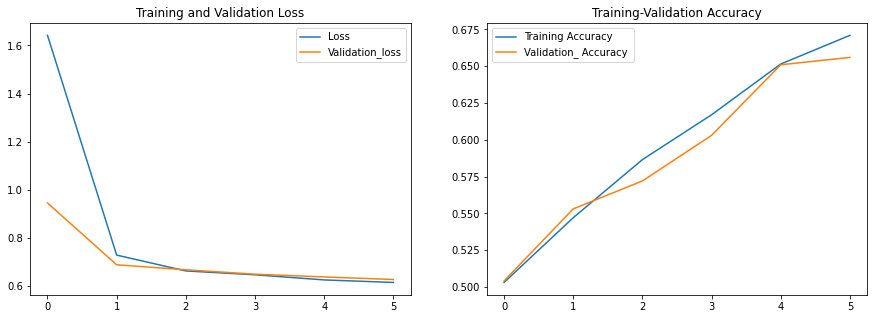

In [66]:
#saving the losses
loss = pd.DataFrame(model.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")

Xception

In [67]:
# Building the body of the model Using VGG19
base_model = tf.keras.applications.Xception(input_shape=(128,128,3), weights="imagenet", include_top=False)

#freaaxing the layer
for layer in base_model.layers:
  layer.trainable= False

83697664/83683744 [==============================] - 0s 0us/step


In [68]:
base_model.summary()

Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_8[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                           

In [69]:
#Creating the Head of the model
model = Flatten()(base_model.output)

model = Dense(units=500, activation="relu")(model)
#model = Dense(units=100, activation="relu")(model)

prediction_layer = Dense(units=2, activation="softmax")(model)

In [70]:
# Joining the head and body
model = Model(inputs= base_model.input, outputs = prediction_layer)

In [71]:
#Summarising the model
model.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_8[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

In [72]:
# Compiling and training 
model.compile(optimizer='adam', loss = "sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])

model.fit_generator(train_gen, epochs=6, validation_data=valid_gen)


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  after removing the cwd from sys.path.


Epoch 1/6
16/16 [==============================] - 16s 740ms/step - loss: 1.7325 - sparse_categorical_accuracy: 0.8820 - val_loss: 0.6651 - val_sparse_categorical_accuracy: 0.9380
Epoch 2/6
16/16 [==============================] - 9s 547ms/step - loss: 0.4207 - sparse_categorical_accuracy: 0.9585 - val_loss: 0.4183 - val_sparse_categorical_accuracy: 0.9490
Epoch 3/6
16/16 [==============================] - 9s 572ms/step - loss: 0.1586 - sparse_categorical_accuracy: 0.9750 - val_loss: 0.4155 - val_sparse_categorical_accuracy: 0.9420
Epoch 4/6
16/16 [==============================] - 9s 557ms/step - loss: 0.0353 - sparse_categorical_accuracy: 0.9895 - val_loss: 0.4578 - val_sparse_categorical_accuracy: 0.9430
Epoch 5/6
16/16 [==============================] - 9s 553ms/step - loss: 0.0310 - sparse_categorical_accuracy: 0.9895 - val_loss: 0.3933 - val_sparse_categorical_accuracy: 0.9450
Epoch 6/6
16/16 [==============================] - 9s 553ms/step - loss: 0.0181 - sparse_categorical_acc

Text(0.5, 1.0, 'Training-Validation Accuracy')

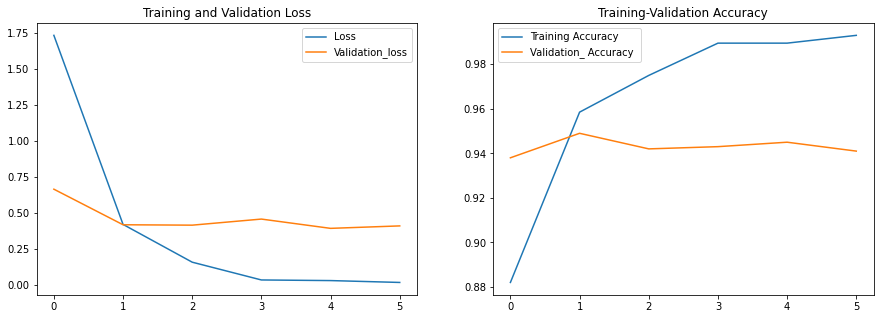

In [73]:
#saving the losses
loss = pd.DataFrame(model.history.history)

#plotting the loss and accuracy
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(loss["loss"], label ="Loss")
plt.plot(loss["val_loss"], label = "Validation_loss")
plt.legend()
plt.title("Training and Validation Loss")

plt.subplot(1,2,2)
plt.plot(loss['sparse_categorical_accuracy'],label = "Training Accuracy")
plt.plot(loss['val_sparse_categorical_accuracy'], label ="Validation_ Accuracy ")
plt.legend()
plt.title("Training-Validation Accuracy")